C=1000 → Accuracy=1.000


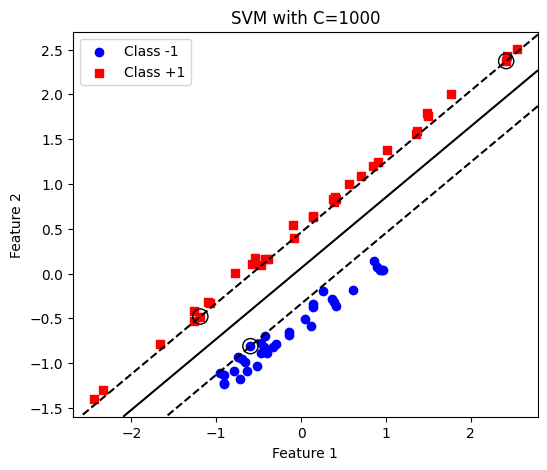

C=1 → Accuracy=1.000


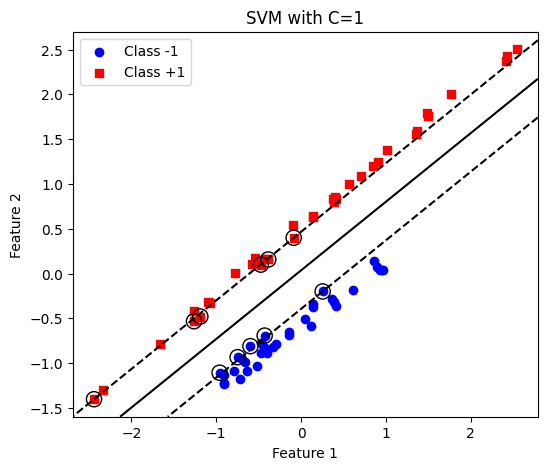

C=0.1 → Accuracy=1.000


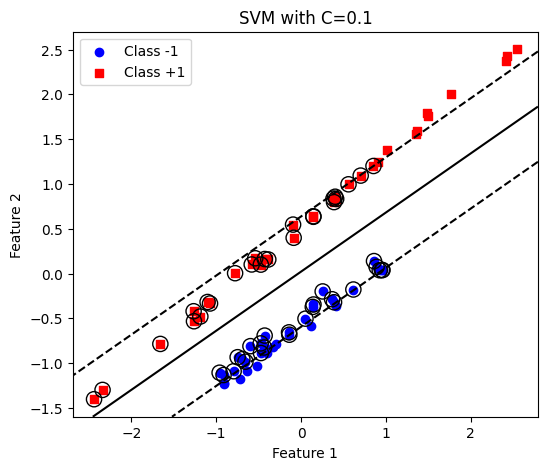

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_classification


X, y = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.5, random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def plot_svm(clf, X, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X[y==0, 0], X[y==0, 1], c="blue", label="Class -1")
    plt.scatter(X[y==1, 0], X[y==1, 1], c="red", marker="s", label="Class +1")

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors="k",
               levels=[-1, 0, 1], linestyles=["--", "-", "--"])

    # Support vectors (circled)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                s=120, facecolors="none", edgecolors="k")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# 5. Train and plot for different C values
C_values = [1000, 1, 0.1]

for C in C_values:
    clf = SVC(kernel="linear", C=C)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    print(f"C={C} → Accuracy={acc:.3f}")
    plot_svm(clf, X_train, y_train, f"SVM with C={C}")
